In [2]:
import pandas as pd
import os
os.chdir('D://My_projects//Drug Use//Final Thesis//alcohol')

In [32]:
import os
os.chdir("D://My_projects//Drug Use//ICPSR_21600-V25//ICPSR_21600//DS0001")

In [33]:
file_path="21600-0001-Data.tsv"

In [34]:
df1 = pd.read_csv(file_path, sep='\t', low_memory=False)

In [69]:
df_all=pd.read_csv('W1-4_fulldata.csv')

C:\Users\pc\AppData\Local\Temp\ipykernel_17444\3597778550.py:1: DtypeWarning: Columns (7,125,126,197,199,357,514,523,524,744,746,747,833,834,838,839,840,847,876,877,878,879,880,881,882,883,884,885,886,887,888,889,890,891,892,893,894,895,896,897,899,900,901,902,903,904,905,906,907,908,909,910,911,912,913,914,915,916,917,918,919,957,958,965,970,971,973,977,978,980,982,983,985,1001,1026,1027,1028,1029,1030,1031,1032,1033,1034,1035,1036,1037,1038,1039,1040,1041,1042,1043,1044,1064,1066,1069,1070,1071,1072,1075,1076,1077,1078,1082,1083,1084,1085,1086,1088,1089,1090,1110,1132,1133,1134,1135,1136,1137,1138,1139,1140,1141,1142,1143,1144,1145,1146,1147,1148,1149,1150,1151,1152,1175,1176,1177,1178,1181,1182,1183,1184,1185,1188,1189,1190,1191,1192,1210,1212,1213,1226,1227,1228,1229,1230,1231,1253,1254,1255,1256,1257,1258,1259,1260,1261,1262,1263,1264,1265,1266,1267,1268,1269,1270,1271,1272,1291,1293,1374,1375,1381,1397,1398,1399,1400,1401,1402,1424,1425,1426,1427,1428,1429,1430,1431,1432,1433,143

In [78]:
for c in df_all.columns:
    if "age" in c.lower():
        print(c)


Age when Moved to Current Residence
Age_StartedSmoking
Age_FirstDrinkNoAdults
Age at First Drink
Age_FirstMarijuana
Age_FirstCocaine
Age_StartedSmoking_Z
Age_FirstDrinkNoAdults_Z
Age_StartedSmoking_rev_Z
Age_FirstDrinkNoAdults_rev_Z
Age_StartRegularSmoking
Age_FirstWholeCig


In [77]:
df_all['Age at First Drink'].describe()

count    2029.000000
mean       14.595367
std         2.137391
min         8.000000
25%        13.000000
50%        15.000000
75%        16.000000
max        20.000000
Name: Age at First Drink, dtype: float64

In [68]:
df_all['IYEAR'].describe()

count    5114.000000
mean       94.999804
std         0.013984
min        94.000000
25%        95.000000
50%        95.000000
75%        95.000000
max        95.000000
Name: IYEAR, dtype: float64

In [3]:
df_all_filtered=pd.read_csv('W1-4_fulldata_filtered.csv')

In [4]:
print([col for col in df_all_filtered.columns if 'index' in col.lower()])


['GPA_Index', 'SchoolTrouble_Index', 'DisciplinaryIndex', 'ParentalWarmth_Index', 'ParentalSupervision_Index', 'Delinquency_Index', 'SportsParticipation_Index', 'MentalDistress_Index', 'SES_Index', 'SexAttitudes_Index', 'SchoolTrouble_Index_Z', 'SchoolBehavior_Index', 'PeerSubstance_Index', 'NeighborhoodCohesion_Index', 'ParentalSupport_Index', 'Support_Index', 'LowReligiosityIndex_W1']


In [7]:
len(df_all_filtered.columns)

210

In [3]:
df_all_filtered = df_all_filtered.drop(columns=["DaysMarijuanaPast12M_W4"], errors="ignore")


In [4]:
import numpy as np
import pandas as pd

# =========================
# USER SETTINGS
# =========================
target = "TotalDrinking"  
corr_thr = 0.09                      # sensible given weak correlations
pair_corr_cut = 0.80                 # multicollinearity screen

# =========================
# 0) Basic numeric-only frame + drop rows missing target
# =========================
df = df_all_filtered.copy()

# Keep numeric predictors only (bool allowed)
numeric_cols = df.select_dtypes(include=[np.number, "bool"]).columns.tolist()

if target not in df.columns:
    raise ValueError(f"Target '{target}' not found in df_all.")

# Ensure target is numeric
if not np.issubdtype(df[target].dtype, np.number):
    df[target] = pd.to_numeric(df[target], errors="coerce")

df = df.dropna(subset=[target])

# Candidate predictors
X_cols_all = [c for c in numeric_cols if c != target]

# Drop near-zero variance columns
low_var = [c for c in X_cols_all if df[c].nunique(dropna=True) <= 1]
X_cols_all = [c for c in X_cols_all if c not in low_var]

# =========================
# 1) Filter by correlation with target
# =========================
corrs = df[X_cols_all + [target]].corr(numeric_only=True)[target].drop(target)
corrs_abs = corrs.abs().sort_values(ascending=False)

corr_keep = corrs_abs[corrs_abs >= corr_thr].index.tolist()

# Relax threshold if too few survive
if len(corr_keep) < 10 and len(corrs_abs) > 0:
    corr_thr_relaxed = max(0.01, corr_thr / 2)
    corr_keep = corrs_abs[corrs_abs >= corr_thr_relaxed].index.tolist()
    print(f"[Info] Relaxed corr threshold to {corr_thr_relaxed:.3f}")
else:
    corr_thr_relaxed = corr_thr

print(f"[Step 1] Kept {len(corr_keep)} vars with |corr| ≥ {corr_thr_relaxed:.3f}")

# =========================
# 2) Remove multicollinearity by pairwise correlation
#    (drop weaker-to-target variable)
# =========================
X_corr = df[corr_keep].corr().abs()

to_drop = set()
cols = X_corr.columns.tolist()

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        c1, c2 = cols[i], cols[j]
        if X_corr.loc[c1, c2] >= pair_corr_cut:
            # drop the weaker variable (lower |corr with target|)
            if corrs_abs[c1] >= corrs_abs[c2]:
                to_drop.add(c2)
            else:
                to_drop.add(c1)

pairwise_keep = [c for c in corr_keep if c not in to_drop]

print(f"[Step 2] Dropped {len(to_drop)} vars with pairwise |corr| ≥ {pair_corr_cut:.2f}")
print(f"[Step 2] Remaining vars: {len(pairwise_keep)}")

# =========================
# 3) Outputs
# =========================
vars_decent_corr = corr_keep
vars_low_multicollinearity = pairwise_keep

print("\n=== FINAL FEATURE SET ===")
print(f"Variables kept (n={len(vars_low_multicollinearity)}):")
for v in vars_low_multicollinearity:
    print(v)


# =========================
# 4) Filtered dataframe (NO imputation)
# =========================
df_filtered = df[vars_low_multicollinearity + [target]].copy()


[Step 1] Kept 50 vars with |corr| ≥ 0.090
[Step 2] Dropped 19 vars with pairwise |corr| ≥ 0.80
[Step 2] Remaining vars: 31

=== FINAL FEATURE SET ===
Variables kept (n=31):
Sex_Female
DaysMarijuanaPast12M_W4
SexAttitudes_Index
SchoolSuspension_Z
Delinquency_Index
SchoolBehavior_Index
Age at First Drink
SchoolTrouble_Index
PeerSubstance_Index
InjuredSomeone
LessLonely_Sex
FriendsRespect_Sex
GPA_Index
Rev_FeelGuilty_Sex
Relax_Sex_Z
SoldDrugs_Z
WantCollege_W1
EverTried_Cigarette_Z
Trouble Paying Attention
PhysicalFight_W1
Attractive_Sex
ExpectCollege_W1
LowReligiosityIndex_W1
Fight_Serious_Z
Trouble_GetAlong_Teachers_W1
Pleasure_Sex
FriendCare_W1
WeaponThreat_W1
DrinkFrequency_Past12mo
HighEduExpectations
Jumped_W1


In [5]:
df = df_filtered.copy()


In [6]:
df.head()

,Sex_Female,DaysMarijuanaPast12M_W4,SexAttitudes_Index,SchoolSuspension_Z,Delinquency_Index,SchoolBehavior_Index,Age at First Drink,SchoolTrouble_Index,PeerSubstance_Index,InjuredSomeone,...,LowReligiosityIndex_W1,Fight_Serious_Z,Trouble_GetAlong_Teachers_W1,Pleasure_Sex,FriendCare_W1,WeaponThreat_W1,DrinkFrequency_Past12mo,HighEduExpectations,Jumped_W1,TotalDrinking
0,1,NaN,0.704868,-0.607756,0.284682,0.467625,16.0,1.75,2.666667,1.0,...,NaN,-0.580644,2.0,4.0,5.0,0.0,3.0,0,0.0,25.0
2,0,6.0,NaN,1.645398,0.624930,0.406031,12.0,1.75,1.333333,1.0,...,0.740869,2.045035,2.0,NaN,5.0,0.0,3.0,0,0.0,48.0
3,0,0.0,NaN,-0.607756,-0.167422,-0.159368,NaN,1.75,0.000000,0.0,...,0.266794,0.732195,1.0,NaN,4.0,0.0,NaN,1,0.0,72.0
4,0,2.0,0.415719,1.645398,-0.351844,0.210727,NaN,0.75,0.000000,0.0,...,-0.207282,-0.580644,1.0,3.0,3.0,1.0,NaN,1,0.0,2.0
6,1,NaN,NaN,-0.607756,-0.331527,-0.309846,NaN,1.00,0.000000,0.0,...,-0.872646,-0.580644,1.0,NaN,4.0,0.0,NaN,1,0.0,2.5


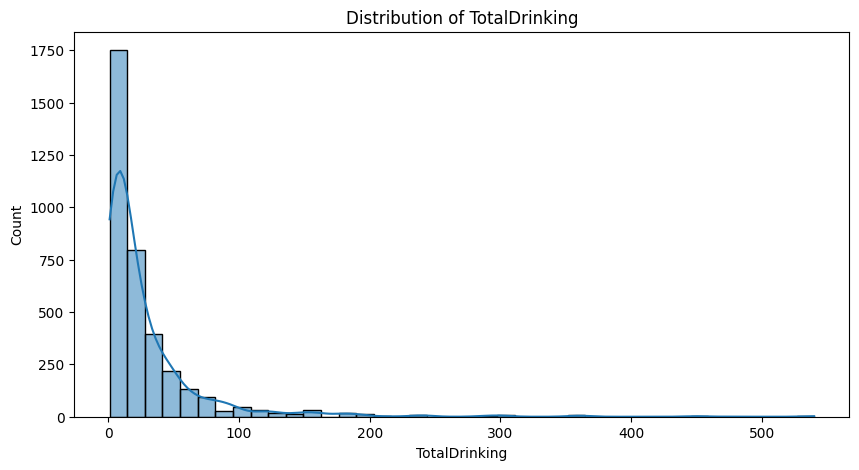

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(df["TotalDrinking"], kde=True, bins=40)
plt.title("Distribution of TotalDrinking")
plt.show()




In [8]:
df = df[df["TotalDrinking"].notna()].copy()


In [9]:
df["heavy_drinker"] = (df["TotalDrinking"] > 40).astype(int)


In [10]:
y = df["heavy_drinker"]

X = df.drop(columns=["TotalDrinking", "heavy_drinker"])


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


In [12]:
print("Train class counts:")
print(y_train.value_counts())

print("\nTest class counts:")
print(y_test.value_counts())


Train class counts:
heavy_drinker
0    2207
1     514
Name: count, dtype: int64

Test class counts:
heavy_drinker
0    736
1    172
Name: count, dtype: int64


## Modeling

## catboost

Running CatBoost RandomizedSearchCV...
Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best CV AUC (tuning, CV=3): 0.7492
Best Parameters (CatBoost):
{'subsample': 0.9, 'rsm': 0.6, 'random_strength': 2, 'learning_rate': 0.01, 'l2_leaf_reg': 12, 'iterations': 800, 'depth': 6, 'class_weights': [1, 3], 'bagging_temperature': 10}

YOUDEN THRESHOLD (TRAIN ONLY, CV=5 OOF)
Youden threshold: 0.3797
Youden J (train OOF): 0.3932
Sensitivity (TPR) @ thr: 0.7198
Specificity (TNR) @ thr: 0.6733

CATBOOST — FINAL TEST PERFORMANCE (YOUDEN)

Test ROC–AUC: 0.7454
Test PR–AUC : 0.3524
Threshold used (Youden, from train OOF): 0.3797

Accuracy : 0.6707
Precision: 0.3298
Recall   : 0.7151
F1-score : 0.4514

Confusion Matrix (Test):
 [[486 250]
 [ 49 123]] 

Classification Report (Test):
              precision    recall  f1-score     support
0              0.908411  0.660326  0.764752  736.000000
1              0.329759  0.715116  0.451376  172.000000
accuracy       0.670705  0.670705  0.670

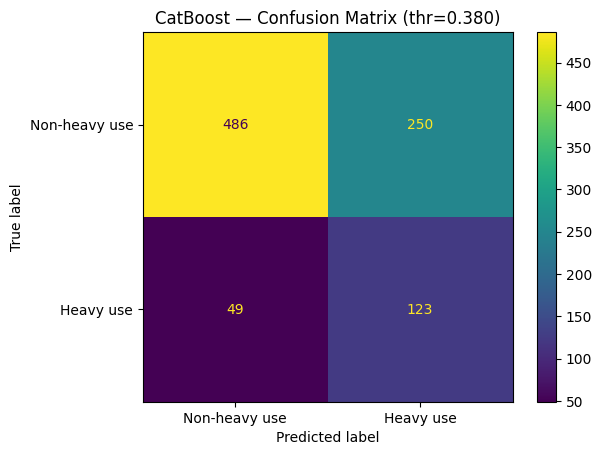

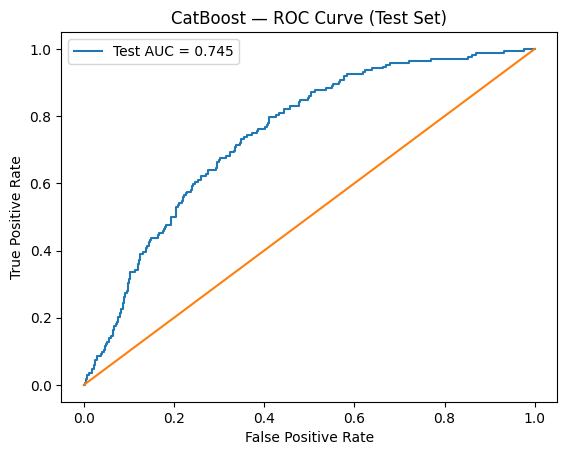

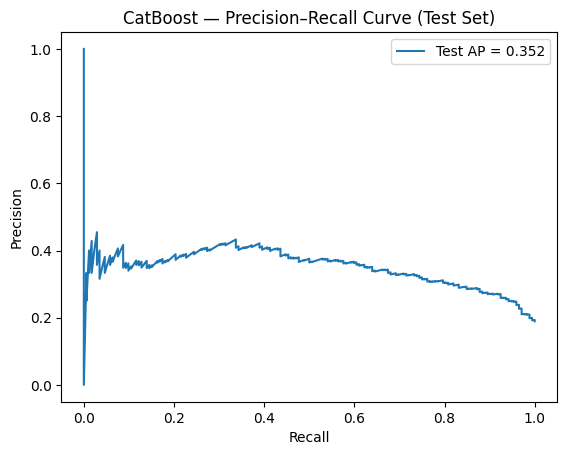

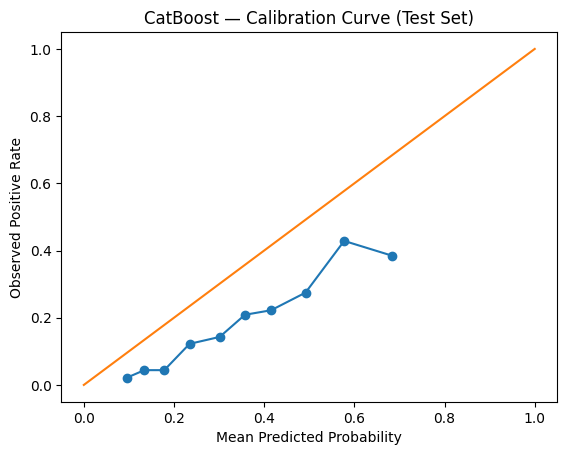

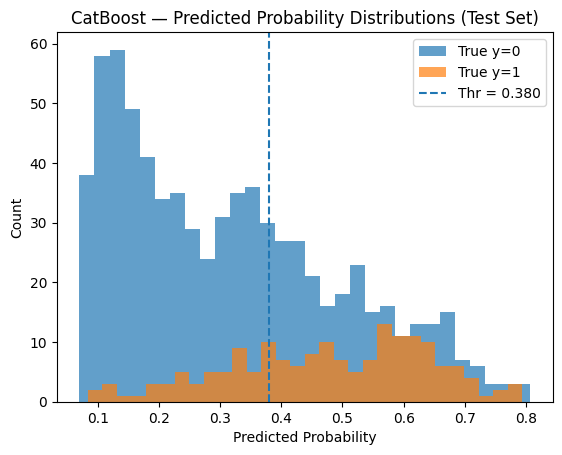


Best CatBoost estimator:


In [15]:
# ============================================================
# CATBOOST — TUNING (CV=3) + YOUDEN (CORRECT: TRAIN-ONLY CV=5 OOF)
# + FINAL TEST METRICS + FIGURES (COLORED CM, ROC, PR, CALIBRATION, PROB DIST)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve

# ----------------------------
# 0) SETTINGS
# ----------------------------
RANDOM_STATE = 42

cv_tune = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)  # tuning CV
cv_youden = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE) # threshold CV

# ----------------------------
# 1) BASE MODEL
# ----------------------------
cat = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False
)

# ----------------------------
# 2) TUNING SPACE
#    Your grid + a couple of useful additions for generalization:
#    - rsm (feature subsampling) helps reduce overfit
#    - bagging_temperature controls bootstrap strength (esp. good for CatBoost)
# ----------------------------
param_dist_cat = {
    "iterations": [400, 800, 1200, 1600],
    "depth": [4, 5, 6, 7, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "l2_leaf_reg": [1, 3, 5, 7, 9, 12, 15],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "random_strength": [0, 1, 2, 5, 10],
    "bagging_temperature": [0, 1, 5, 10],
    "rsm": [0.6, 0.8, 1.0],
    # your class-weights tuning (fine)
    "class_weights": [[1, 3], [1, 5], [1, 7], [1, 10]]
}

rs_cat = RandomizedSearchCV(
    estimator=cat,
    param_distributions=param_dist_cat,
    n_iter=40,
    scoring="roc_auc",
    cv=cv_tune,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=False
)

print("Running CatBoost RandomizedSearchCV...")
rs_cat.fit(X_train2, y_train)

print("\nBest CV AUC (tuning, CV=3):", round(rs_cat.best_score_, 4))
print("Best Parameters (CatBoost):")
print(rs_cat.best_params_)

best_cat = rs_cat.best_estimator_  # refit=True by default


# ----------------------------
# 3) YOUDEN THRESHOLD (CORRECT WAY): TRAIN ONLY, CV=5 OOF PROBS
# ----------------------------
def youden_from_probs(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    youden_j = tpr - fpr
    best_idx = np.argmax(youden_j)
    return thresholds[best_idx], youden_j[best_idx], fpr, tpr, thresholds, youden_j, best_idx

oof_prob = cross_val_predict(
    best_cat,
    X_train2, y_train,
    cv=cv_youden,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

youden_thr, youden_j_best, fpr_oof, tpr_oof, thr_oof, youden_j_all, best_idx = youden_from_probs(y_train, oof_prob)

print("\n===============================================")
print("YOUDEN THRESHOLD (TRAIN ONLY, CV=5 OOF)")
print("===============================================")
print("Youden threshold:", round(youden_thr, 4))
print("Youden J (train OOF):", round(youden_j_best, 4))
print("Sensitivity (TPR) @ thr:", round(tpr_oof[best_idx], 4))
print("Specificity (TNR) @ thr:", round(1 - fpr_oof[best_idx], 4))


# ----------------------------
# 4) FINAL MODEL FIT ON FULL TRAIN + SINGLE TEST EVALUATION
# ----------------------------
best_cat.fit(X_train2, y_train)

y_prob_test = best_cat.predict_proba(X_test2)[:, 1]
y_pred_test = (y_prob_test >= youden_thr).astype(int)

test_auc = roc_auc_score(y_test, y_prob_test)
test_ap  = average_precision_score(y_test, y_prob_test)

cm = confusion_matrix(y_test, y_pred_test)

acc  = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, zero_division=0)
rec  = recall_score(y_test, y_pred_test, zero_division=0)
f1   = f1_score(y_test, y_pred_test, zero_division=0)

print("\n===============================================")
print("CATBOOST — FINAL TEST PERFORMANCE (YOUDEN)")
print("===============================================\n")
print(f"Test ROC–AUC: {test_auc:.4f}")
print(f"Test PR–AUC : {test_ap:.4f}")
print(f"Threshold used (Youden, from train OOF): {youden_thr:.4f}\n")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}\n")

print("Confusion Matrix (Test):\n", cm, "\n")

print("Classification Report (Test):")
print(pd.DataFrame(classification_report(y_test, y_pred_test, output_dict=True)).T)

# Summary table (handy for thesis)
summary = pd.DataFrame({
    "Metric": [
        "CV ROC–AUC (tuning, best)",
        "Youden threshold (train OOF, CV=5)",
        "Youden J (train OOF, CV=5)",
        "Test ROC–AUC",
        "Test PR–AUC",
        "Test Accuracy",
        "Test Precision (class 1)",
        "Test Recall (class 1)",
        "Test F1 (class 1)"
    ],
    "Value": [
        rs_cat.best_score_,
        youden_thr,
        youden_j_best,
        test_auc,
        test_ap,
        acc,
        prec,
        rec,
        f1
    ]
}).round(4)

print("\nFinal Performance Summary:")
print(summary)


# ============================================================
# 5) FIGURES
# ============================================================

# 5.1 COLORED CONFUSION MATRIX (Matplotlib colormap)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-heavy use", "Heavy use"]
)
fig, ax = plt.subplots()
disp.plot(ax=ax)
ax.set_title(f"CatBoost — Confusion Matrix (thr={youden_thr:.3f})")
plt.show()

# 5.2 ROC CURVE (TEST)
fpr_test, tpr_test, _ = roc_curve(y_test, y_prob_test)
plt.figure()
plt.plot(fpr_test, tpr_test, label=f"Test AUC = {test_auc:.3f}")
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CatBoost — ROC Curve (Test Set)")
plt.legend()
plt.show()

# 5.3 PRECISION–RECALL CURVE (TEST)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob_test)
plt.figure()
plt.plot(rec_curve, prec_curve, label=f"Test AP = {test_ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("CatBoost — Precision–Recall Curve (Test Set)")
plt.legend()
plt.show()

# 5.4 CALIBRATION CURVE (TEST)
prob_true, prob_pred = calibration_curve(y_test, y_prob_test, n_bins=10, strategy="quantile")
plt.figure()
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1])
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Positive Rate")
plt.title("CatBoost — Calibration Curve (Test Set)")
plt.show()

# 5.5 PROBABILITY DISTRIBUTIONS (TEST) + THRESHOLD
y_test_np = np.asarray(y_test)
plt.figure()
plt.hist(y_prob_test[y_test_np == 0], bins=30, alpha=0.7, label="True y=0")
plt.hist(y_prob_test[y_test_np == 1], bins=30, alpha=0.7, label="True y=1")
plt.axvline(youden_thr, linestyle="--", label=f"Thr = {youden_thr:.3f}")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("CatBoost — Predicted Probability Distributions (Test Set)")
plt.legend()
plt.show()

print("\nBest CatBoost estimator:")
print(best_cat)


In [21]:
from catboost import CatBoostClassifier

best_cat = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=False,
    allow_writing_files=False,

    subsample=0.9,
    rsm=0.6,
    random_strength=2,
    learning_rate=0.01,
    l2_leaf_reg=12,
    iterations=800,
    depth=6,
    class_weights=[1, 3],
    bagging_temperature=10
)

best_cat.fit(X_train2, y_train)

print(" Best CatBoost model fitted on full training data.")
print(best_cat)


 Best CatBoost model fitted on full training data.


In [22]:
from sklearn.metrics import roc_auc_score
X_test2=X_test.copy()
# Predicted probabilities for class 1
y_prob_test = best_cat.predict_proba(X_test2)[:, 1]

# Test ROC–AUC
test_auc = roc_auc_score(y_test, y_prob_test)

print(f"CatBoost Test ROC–AUC (Marijuana, cutoff=4): {test_auc:.4f}")


CatBoost Test ROC–AUC (Marijuana, cutoff=4): 0.7454


X_bg dtype: [dtype('float32')]
X_test dtype: [dtype('float32')]


 99%|===================| 901/908 [00:39<00:00]        

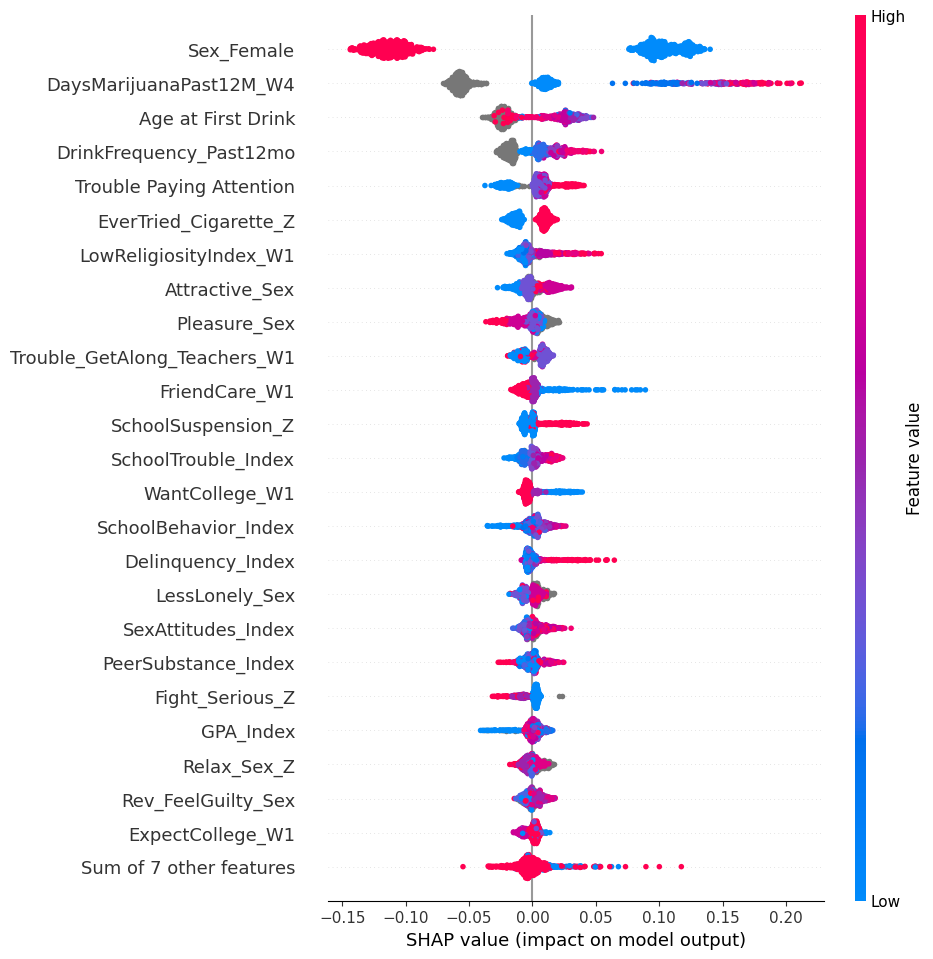

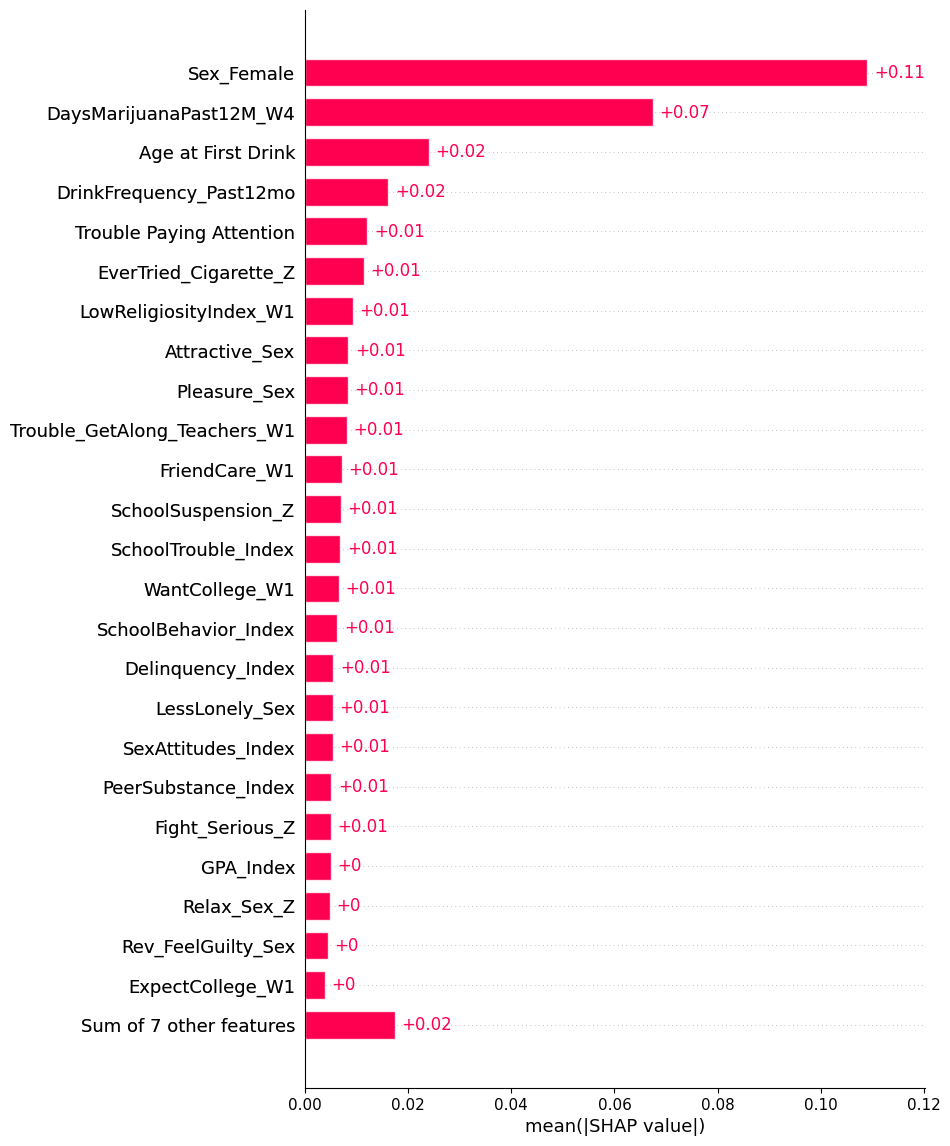

Top SHAP features: ['Sex_Female', 'DaysMarijuanaPast12M_W4', 'Age at First Drink', 'DrinkFrequency_Past12mo', 'Trouble Paying Attention', 'EverTried_Cigarette_Z', 'LowReligiosityIndex_W1', 'Attractive_Sex', 'Pleasure_Sex', 'Trouble_GetAlong_Teachers_W1']


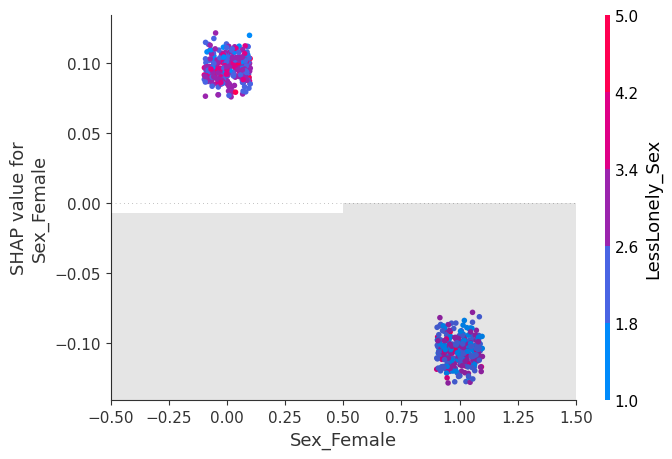

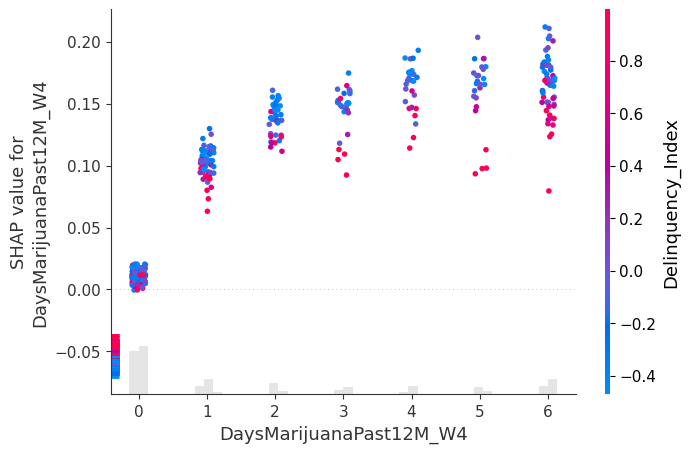

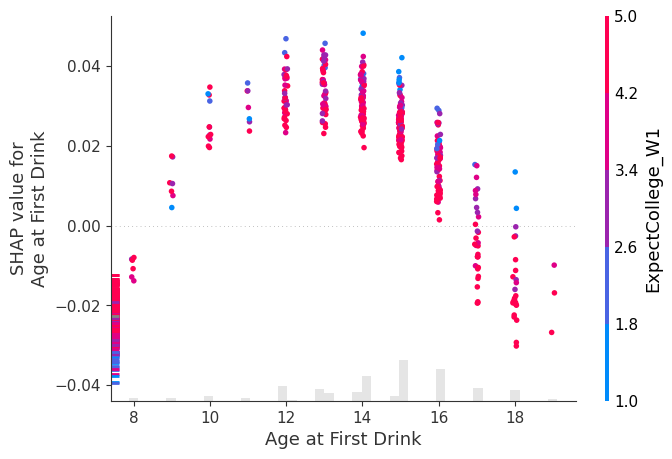

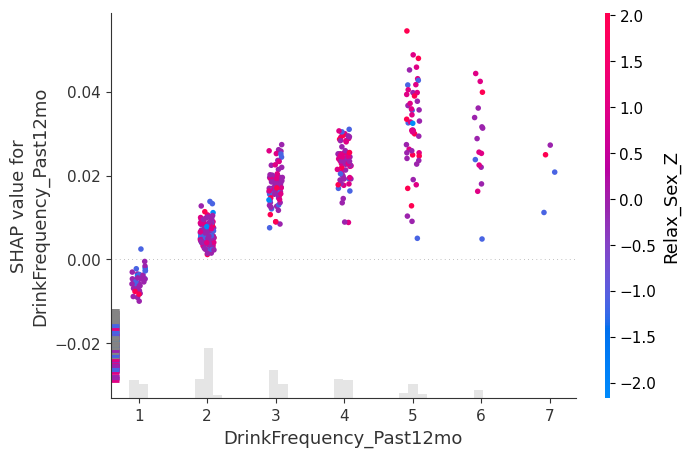

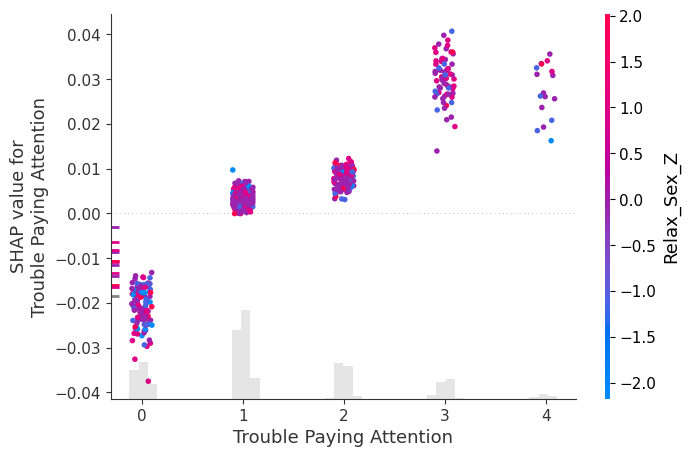

Explaining test row index: 357


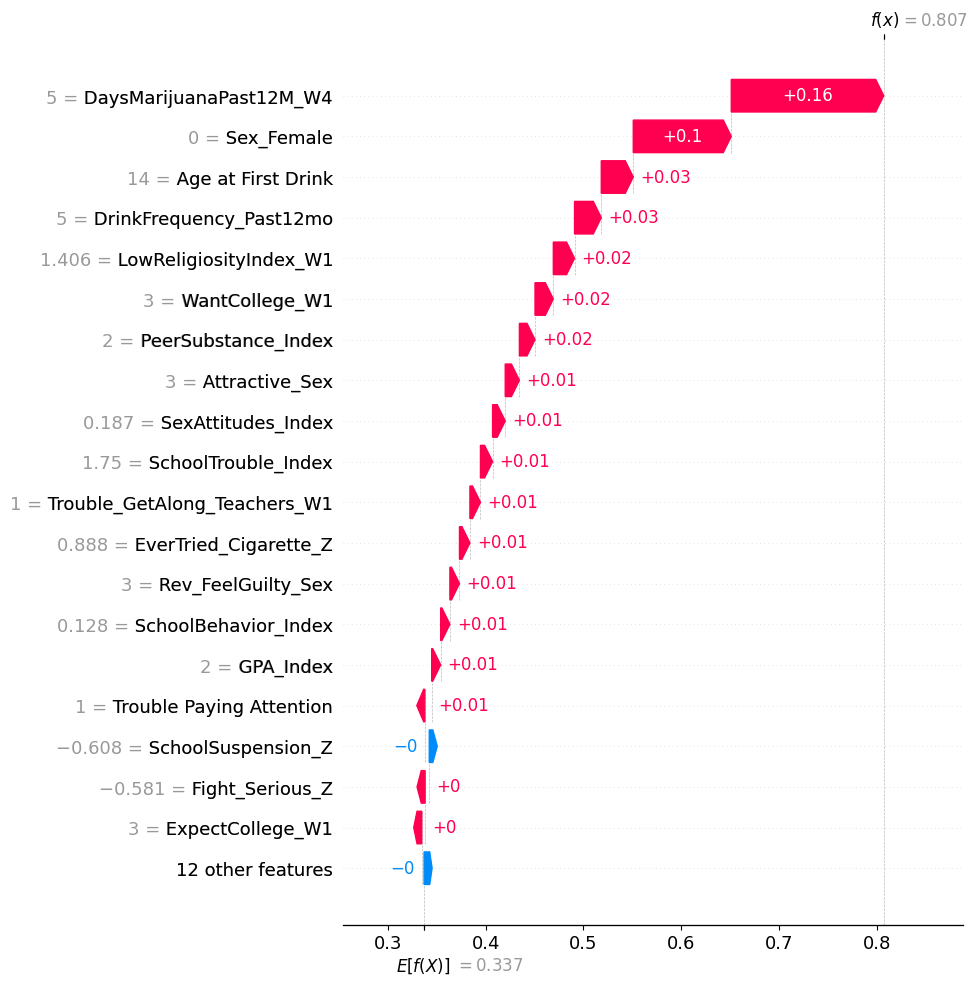

In [23]:
# ============================
# SHAP analysis for best_cat (CatBoost)
# ============================
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 0) Make sure X_* are DataFrames (keeps feature names)
X_train_cb = X_train2.copy()
X_test_cb  = X_test2.copy()

if not isinstance(X_train_cb, pd.DataFrame):
    X_train_cb = pd.DataFrame(X_train_cb)
if not isinstance(X_test_cb, pd.DataFrame):
    X_test_cb = pd.DataFrame(X_test_cb)

feature_names = X_train_cb.columns.tolist()

# 1) Optional: clean dtypes (bool -> int, everything numeric)
def force_numeric(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    bool_cols = df.select_dtypes(include=["bool"]).columns
    df[bool_cols] = df[bool_cols].astype(np.int8)

    # If anything is object, try coercing to numeric (will raise if truly non-numeric)
    obj_cols = df.select_dtypes(include=["object"]).columns
    if len(obj_cols) > 0:
        df[obj_cols] = df[obj_cols].apply(pd.to_numeric, errors="raise")

    return df.astype(np.float32)

X_train_shap = force_numeric(X_train_cb)
X_test_shap  = force_numeric(X_test_cb)

# 2) Background sample (recommended for speed)
bg_size = min(200, len(X_train_shap))
X_bg = X_train_shap.sample(bg_size, random_state=42)

print("X_bg dtype:", X_bg.dtypes.unique())
print("X_test dtype:", X_test_shap.dtypes.unique())

# 3) SHAP explainer (TreeExplainer is ideal for CatBoost)
#    model_output="probability" makes SHAP values correspond to predicted probability (class 1).
explainer = shap.TreeExplainer(best_cat, data=X_bg, model_output="probability")
shap_values = explainer(X_test_shap)  # returns Explanation

# 4) Global: beeswarm + bar
shap.plots.beeswarm(shap_values, max_display=25)
shap.plots.bar(shap_values, max_display=25)

# ---------------------------------------------------------
# B) DEPENDENCE: top features (scatter plots)
# ---------------------------------------------------------
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
top_idx = np.argsort(mean_abs_shap)[::-1][:10]
top_features = X_test_shap.columns[top_idx].tolist()

print("Top SHAP features:", top_features)

for feat in top_features[:5]:
    shap.plots.scatter(shap_values[:, feat], color=shap_values)

# ---------------------------------------------------------
# C) LOCAL: explain a single prediction
# ---------------------------------------------------------
# Choose instance = highest predicted risk (class 1 prob)
idx = int(np.argmax(best_cat.predict_proba(X_test_cb)[:, 1]))
print("Explaining test row index:", idx)

shap.plots.waterfall(shap_values[idx], max_display=20)

# Force plot (interactive in notebooks)
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values.values[idx, :],
    X_test_cb.iloc[idx, :],
)

# ---------------------------------------------------------
# D) (Optional) SHAP values table export
# ---------------------------------------------------------
shap_df = pd.DataFrame(shap_values.values, columns=feature_names)
shap_df["pred_prob"] = best_cat.predict_proba(X_test_cb)[:, 1]
shap_df["y_true"] = np.asarray(y_test)

# shap_df.to_csv("shap_values_test_catboost.csv", index=False)


## XGBoost with tuning

Running XGBoost RandomizedSearchCV...
Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best CV AUC (tuning, CV=3): 0.7523
Best Parameters (XGBoost):
{'subsample': 0.6, 'reg_lambda': 5, 'reg_alpha': 0.01, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 10, 'max_delta_step': 0, 'learning_rate': 0.01, 'gamma': 5, 'colsample_bytree': 0.6}

YOUDEN THRESHOLD (TRAIN ONLY, CV=5 OOF)
Youden threshold: 0.4505
Youden J (train OOF): 0.3844
Sensitivity (TPR) @ thr: 0.6907
Specificity (TNR) @ thr: 0.6937

XGBOOST — FINAL TEST PERFORMANCE (YOUDEN)

Test ROC–AUC: 0.7233
Test PR–AUC : 0.3334
Threshold used (Youden, from train OOF): 0.4505

Accuracy : 0.6839
Precision: 0.3314
Recall   : 0.6570
F1-score : 0.4405

Confusion Matrix (Test):
 [[508 228]
 [ 59 113]] 

Classification Report (Test):
              precision    recall  f1-score     support
0              0.895944  0.690217  0.779739  736.000000
1              0.331378  0.656977  0.440546  172.000000
accuracy       0.683921 

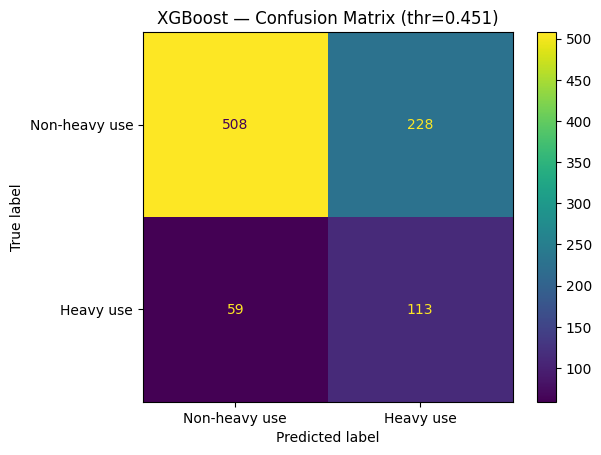

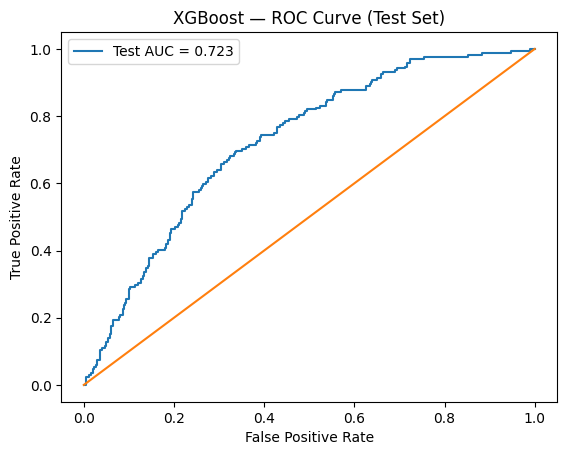

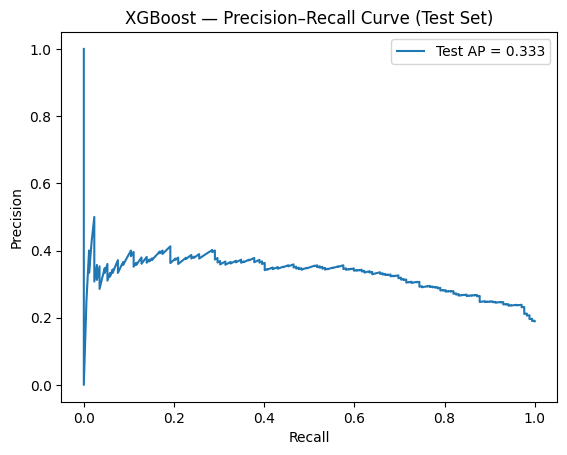

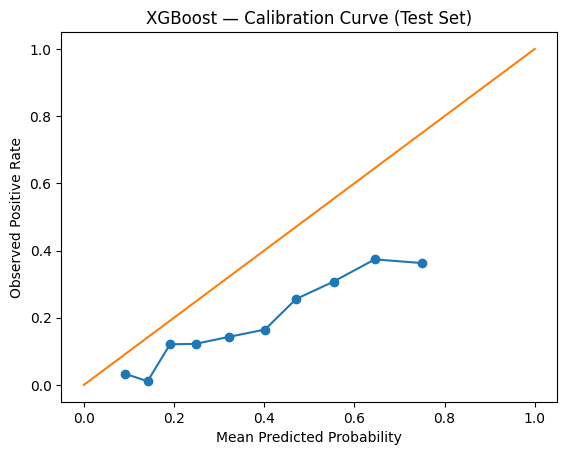

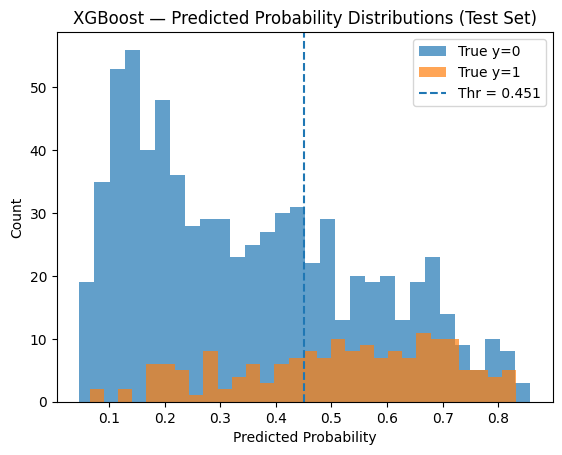


Best XGBoost estimator:
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=5,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=0,
              max_depth=10, max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, ...)


In [16]:
# ============================================================
# XGBOOST — TUNING (CV=3) + YOUDEN (CORRECT: TRAIN-ONLY CV=5 OOF)
# + FINAL TEST METRICS + FIGURES (COLORED CM, ROC, PR, CALIBRATION, PROB DIST)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve

# ----------------------------
# 0) COPIES + IMBALANCE RATIO
# ----------------------------
X_train2 = X_train.copy()
X_test2  = X_test.copy()

pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos = neg / pos

RANDOM_STATE = 42
cv_tune   = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv_youden = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ----------------------------
# 1) BASE MODEL
# ----------------------------
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",          # stable for training; AUC used in CV scoring
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scale_pos_weight=scale_pos
)

# ----------------------------
# 2) TUNING SPACE (your grid + useful additions)
#    Additions:
#    - reg_lambda & reg_alpha already included (good)
#    - min_child_weight already included (good)
#    - max_delta_step sometimes stabilizes imbalanced logistic loss (optional)
# ----------------------------
param_dist_xgb = {
    "n_estimators": [300, 500, 800, 1200, 1600],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6, 8, 10],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 8, 12],
    "gamma": [0, 0.5, 1, 2, 5],
    "reg_lambda": [0.5, 1, 2, 5, 10],
    "reg_alpha": [0, 0.01, 0.1, 0.5, 1],
    "max_delta_step": [0, 1, 5]     # optional stabilizer for imbalance
}

rs_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    n_iter=40,
    scoring="roc_auc",
    cv=cv_tune,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=False
)

print("Running XGBoost RandomizedSearchCV...")
rs_xgb.fit(X_train2, y_train)

print("\nBest CV AUC (tuning, CV=3):", round(rs_xgb.best_score_, 4))
print("Best Parameters (XGBoost):")
print(rs_xgb.best_params_)

best_xgb = rs_xgb.best_estimator_  # refit=True by default


# ----------------------------
# 3) YOUDEN THRESHOLD (CORRECT WAY): TRAIN ONLY, CV=5 OOF PROBS
# ----------------------------
def youden_from_probs(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    youden_j = tpr - fpr
    best_idx = np.argmax(youden_j)
    return thresholds[best_idx], youden_j[best_idx], fpr, tpr, thresholds, youden_j, best_idx

oof_prob = cross_val_predict(
    best_xgb,
    X_train2, y_train,
    cv=cv_youden,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

youden_thr, youden_j_best, fpr_oof, tpr_oof, thr_oof, youden_j_all, best_idx = youden_from_probs(y_train, oof_prob)

print("\n===============================================")
print("YOUDEN THRESHOLD (TRAIN ONLY, CV=5 OOF)")
print("===============================================")
print("Youden threshold:", round(youden_thr, 4))
print("Youden J (train OOF):", round(youden_j_best, 4))
print("Sensitivity (TPR) @ thr:", round(tpr_oof[best_idx], 4))
print("Specificity (TNR) @ thr:", round(1 - fpr_oof[best_idx], 4))


# ----------------------------
# 4) FINAL MODEL FIT ON FULL TRAIN + SINGLE TEST EVALUATION
# ----------------------------
best_xgb.fit(X_train2, y_train)

y_prob_test = best_xgb.predict_proba(X_test2)[:, 1]
y_pred_test = (y_prob_test >= youden_thr).astype(int)

test_auc = roc_auc_score(y_test, y_prob_test)
test_ap  = average_precision_score(y_test, y_prob_test)

cm = confusion_matrix(y_test, y_pred_test)

acc  = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, zero_division=0)
rec  = recall_score(y_test, y_pred_test, zero_division=0)
f1   = f1_score(y_test, y_pred_test, zero_division=0)

print("\n===============================================")
print("XGBOOST — FINAL TEST PERFORMANCE (YOUDEN)")
print("===============================================\n")
print(f"Test ROC–AUC: {test_auc:.4f}")
print(f"Test PR–AUC : {test_ap:.4f}")
print(f"Threshold used (Youden, from train OOF): {youden_thr:.4f}\n")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}\n")

print("Confusion Matrix (Test):\n", cm, "\n")

print("Classification Report (Test):")
print(pd.DataFrame(classification_report(y_test, y_pred_test, output_dict=True)).T)

# Summary table (handy for thesis)
summary = pd.DataFrame({
    "Metric": [
        "CV ROC–AUC (tuning, best)",
        "Youden threshold (train OOF, CV=5)",
        "Youden J (train OOF, CV=5)",
        "Test ROC–AUC",
        "Test PR–AUC",
        "Test Accuracy",
        "Test Precision (class 1)",
        "Test Recall (class 1)",
        "Test F1 (class 1)"
    ],
    "Value": [
        rs_xgb.best_score_,
        youden_thr,
        youden_j_best,
        test_auc,
        test_ap,
        acc,
        prec,
        rec,
        f1
    ]
}).round(4)

print("\nFinal Performance Summary:")
print(summary)


# ============================================================
# 5) FIGURES
# ============================================================

# 5.1 COLORED CONFUSION MATRIX (Matplotlib colormap)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-heavy use", "Heavy use"]
)
fig, ax = plt.subplots()
disp.plot(ax=ax)
ax.set_title(f"XGBoost — Confusion Matrix (thr={youden_thr:.3f})")
plt.show()

# 5.2 ROC CURVE (TEST)
fpr_test, tpr_test, _ = roc_curve(y_test, y_prob_test)
plt.figure()
plt.plot(fpr_test, tpr_test, label=f"Test AUC = {test_auc:.3f}")
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost — ROC Curve (Test Set)")
plt.legend()
plt.show()

# 5.3 PRECISION–RECALL CURVE (TEST)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob_test)
plt.figure()
plt.plot(rec_curve, prec_curve, label=f"Test AP = {test_ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("XGBoost — Precision–Recall Curve (Test Set)")
plt.legend()
plt.show()

# 5.4 CALIBRATION CURVE (TEST)
prob_true, prob_pred = calibration_curve(y_test, y_prob_test, n_bins=10, strategy="quantile")
plt.figure()
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1])
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Positive Rate")
plt.title("XGBoost — Calibration Curve (Test Set)")
plt.show()

# 5.5 PROBABILITY DISTRIBUTIONS (TEST) + THRESHOLD
y_test_np = np.asarray(y_test)
plt.figure()
plt.hist(y_prob_test[y_test_np == 0], bins=30, alpha=0.7, label="True y=0")
plt.hist(y_prob_test[y_test_np == 1], bins=30, alpha=0.7, label="True y=1")
plt.axvline(youden_thr, linestyle="--", label=f"Thr = {youden_thr:.3f}")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("XGBoost — Predicted Probability Distributions (Test Set)")
plt.legend()
plt.show()

print("\nBest XGBoost estimator:")
print(best_xgb)


## Logistic (L2)

Best C (from tuning): 0.004641588833612777

 Youden threshold (TRAIN OOF, CV=5): 0.4893
 Youden J: 0.3744
 Sensitivity: 0.7237
 Specificity: 0.6507

 LOGISTIC REGRESSION (L2) — TEST RESULTS
Test AUC: 0.7118
Test PR–AUC: 0.3442
Threshold used (Youden): 0.4893

Confusion Matrix:
 [[461 275]
 [ 52 120]]

Classification Report:
               precision    recall  f1-score   support

           0      0.899     0.626     0.738       736
           1      0.304     0.698     0.423       172

    accuracy                          0.640       908
   macro avg      0.601     0.662     0.581       908
weighted avg      0.786     0.640     0.679       908



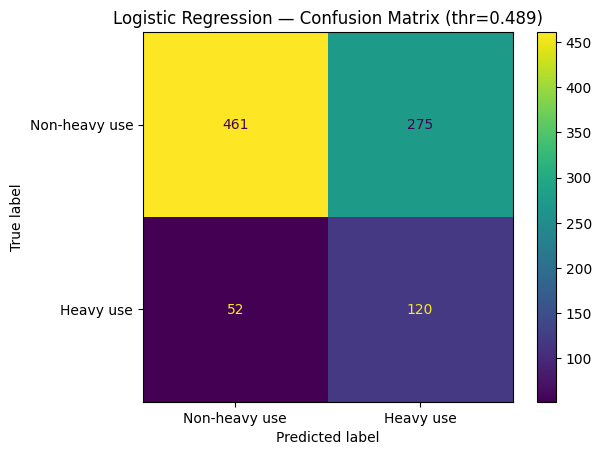

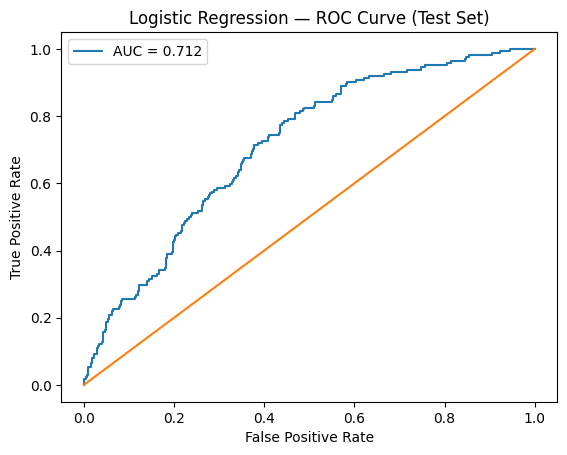

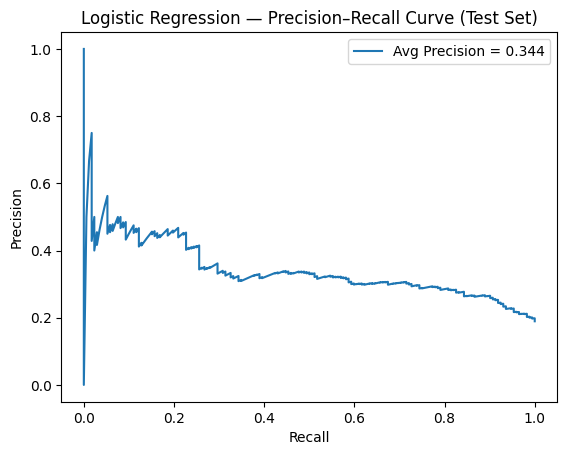

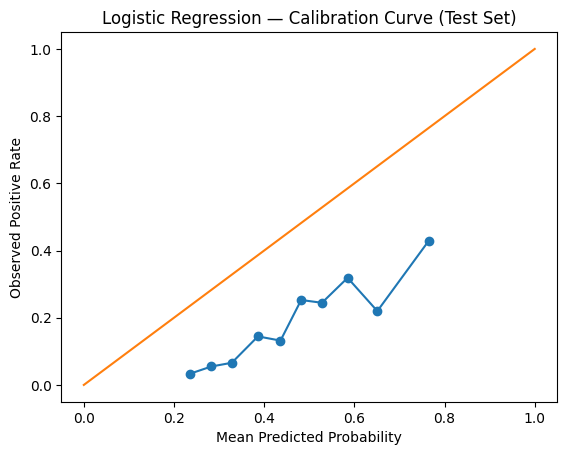

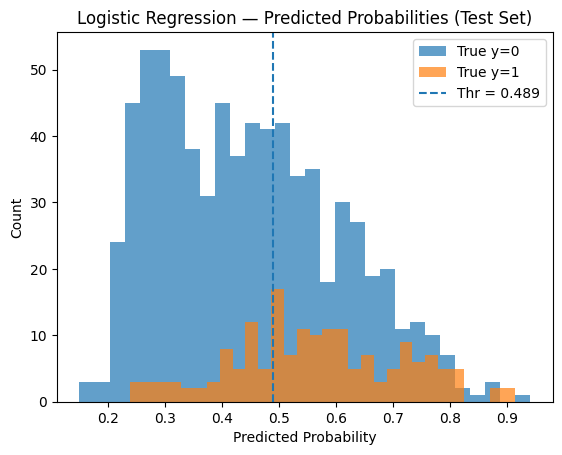


Top positive coefficients (higher risk):
                     feature      coef  odds_ratio  abs_coef
1    DaysMarijuanaPast12M_W4  0.202382    1.224316  0.202382
17     EverTried_Cigarette_Z  0.104922    1.110624  0.104922
22    LowReligiosityIndex_W1  0.104595    1.110261  0.104595
18  Trouble Paying Attention  0.098643    1.103672  0.098643
4          Delinquency_Index  0.084144    1.087786  0.084144
20            Attractive_Sex  0.081386    1.084790  0.081386
3         SchoolSuspension_Z  0.067830    1.070184  0.067830
7        SchoolTrouble_Index  0.057076    1.058737  0.057076
2         SexAttitudes_Index  0.047948    1.049116  0.047948
13        Rev_FeelGuilty_Sex  0.040863    1.041710  0.040863
8        PeerSubstance_Index  0.036401    1.037071  0.036401
14               Relax_Sex_Z  0.024886    1.025198  0.024886
10            LessLonely_Sex  0.021372    1.021602  0.021372
9             InjuredSomeone  0.021137    1.021362  0.021137
21          ExpectCollege_W1  0.021108    1

In [17]:
# ============================================================
# LOGISTIC REGRESSION (L2) — TUNING + YOUDEN (CORRECT WAY)
# + FINAL TEST METRICS + FIGURES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve


# ------------------------------------------------
# 0) Copies
# ------------------------------------------------
X_train2 = X_train.copy()
X_test2  = X_test.copy()
y_train_np = np.asarray(y_train)


# ------------------------------------------------
# 1) Helper: Youden threshold
# ------------------------------------------------
def youden_threshold(y_true, y_prob):
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    j = tpr - fpr
    idx = np.argmax(j)
    return thr[idx], j[idx], tpr[idx], 1 - fpr[idx]


# ------------------------------------------------
# 2) TUNED LOGISTIC REGRESSION (L2)
# ------------------------------------------------
pipe_lr = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("lr", LogisticRegressionCV(
        Cs=np.logspace(-4, 4, 25),      # explicit, transparent tuning grid
        cv=3,                           # tuning CV
        penalty="l2",
        solver="liblinear",
        scoring="roc_auc",
        class_weight="balanced",
        max_iter=5000,
        refit=True
    ))
])

# Fit FINAL model on full training set
pipe_lr.fit(X_train2, y_train)

best_C = pipe_lr.named_steps["lr"].C_[0]
print("Best C (from tuning):", best_C)


# ------------------------------------------------
# 3) YOUDEN THRESHOLD (CORRECT: TRAIN ONLY, CV=5 OOF)
# ------------------------------------------------
cv_youden = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_prob = cross_val_predict(
    pipe_lr,
    X_train2,
    y_train,
    cv=cv_youden,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

best_thr, best_j, sens, spec = youden_threshold(y_train, oof_prob)

print("\n=======================================")
print(" Youden threshold (TRAIN OOF, CV=5):", round(best_thr, 4))
print(" Youden J:", round(best_j, 4))
print(" Sensitivity:", round(sens, 4))
print(" Specificity:", round(spec, 4))
print("=======================================")


# ------------------------------------------------
# 4) FINAL TEST EVALUATION (single report)
# ------------------------------------------------
y_prob_test = pipe_lr.predict_proba(X_test2)[:, 1]
test_auc = roc_auc_score(y_test, y_prob_test)
ap = average_precision_score(y_test, y_prob_test)

y_pred_test = (y_prob_test >= best_thr).astype(int)
cm = confusion_matrix(y_test, y_pred_test)

print("\n=======================================")
print(" LOGISTIC REGRESSION (L2) — TEST RESULTS")
print("=======================================")
print("Test AUC:", round(test_auc, 4))
print("Test PR–AUC:", round(ap, 4))
print("Threshold used (Youden):", round(best_thr, 4))
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_test, digits=3))


# ============================================================
# 5) FIGURES
# ============================================================

# 5.1 Colored Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-heavy use", "Heavy use"]
)
fig, ax = plt.subplots()
disp.plot(ax=ax)
ax.set_title(f"Logistic Regression — Confusion Matrix (thr={best_thr:.3f})")
plt.show()


# 5.2 ROC Curve (TEST)
fpr, tpr, _ = roc_curve(y_test, y_prob_test)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {test_auc:.3f}")
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression — ROC Curve (Test Set)")
plt.legend()
plt.show()


# 5.3 Precision–Recall Curve (TEST)
prec, rec, _ = precision_recall_curve(y_test, y_prob_test)

plt.figure()
plt.plot(rec, prec, label=f"Avg Precision = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Logistic Regression — Precision–Recall Curve (Test Set)")
plt.legend()
plt.show()


# 5.4 Calibration Curve (TEST)
prob_true, prob_pred = calibration_curve(
    y_test, y_prob_test, n_bins=10, strategy="quantile"
)

plt.figure()
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1])
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Positive Rate")
plt.title("Logistic Regression — Calibration Curve (Test Set)")
plt.show()


# 5.5 Probability Distributions (TEST) + threshold
y_test_np = np.asarray(y_test)

plt.figure()
plt.hist(y_prob_test[y_test_np == 0], bins=30, alpha=0.7, label="True y=0")
plt.hist(y_prob_test[y_test_np == 1], bins=30, alpha=0.7, label="True y=1")
plt.axvline(best_thr, linestyle="--", label=f"Thr = {best_thr:.3f}")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Logistic Regression — Predicted Probabilities (Test Set)")
plt.legend()
plt.show()


# ------------------------------------------------
# 6) COEFFICIENTS (FINAL, INTERPRETABLE)
# ------------------------------------------------
coef = pipe_lr.named_steps["lr"].coef_[0]
coef_df = pd.DataFrame({
    "feature": X_train2.columns,
    "coef": coef
}).sort_values("coef", ascending=False)
coef_df["odds_ratio"] = np.exp(coef_df["coef"])
coef_df["abs_coef"] = coef_df["coef"].abs()

print("\nTop positive coefficients (higher risk):")
print(coef_df.head(15))

print("\nTop negative coefficients (protective):")
print(coef_df.tail(15))


## ElasticNet


Best C (from tuning): 0.012742749857031334
Best l1_ratio (from tuning): 0.1

 Youden threshold (TRAIN OOF, CV=5): 0.4737
 Youden J: 0.3688
 Sensitivity: 0.7412
 Specificity: 0.6275

 ELASTIC NET LOGISTIC — TEST RESULTS
Test AUC: 0.7178
Test PR–AUC: 0.3441
Threshold used (Youden): 0.4737

Confusion Matrix:
 [[455 281]
 [ 48 124]]

Classification Report:
               precision    recall  f1-score   support

           0      0.905     0.618     0.734       736
           1      0.306     0.721     0.430       172

    accuracy                          0.638       908
   macro avg      0.605     0.670     0.582       908
weighted avg      0.791     0.638     0.677       908



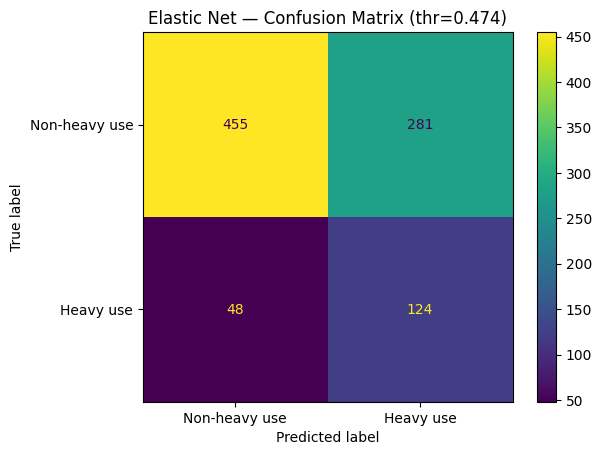

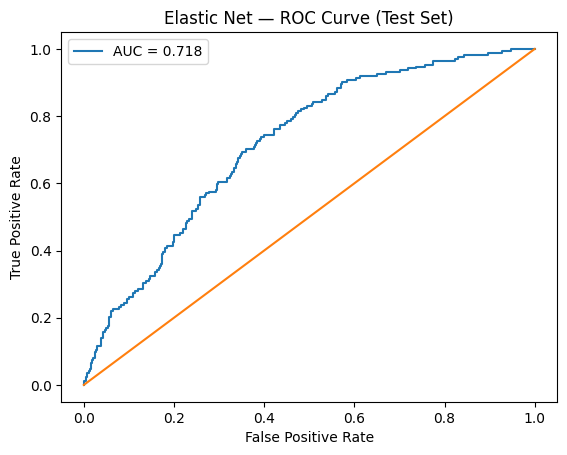

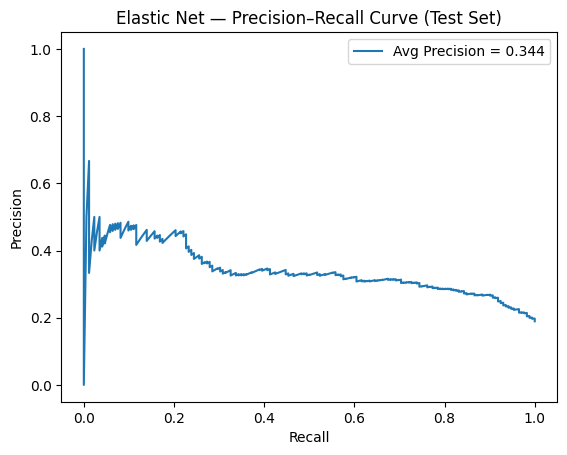

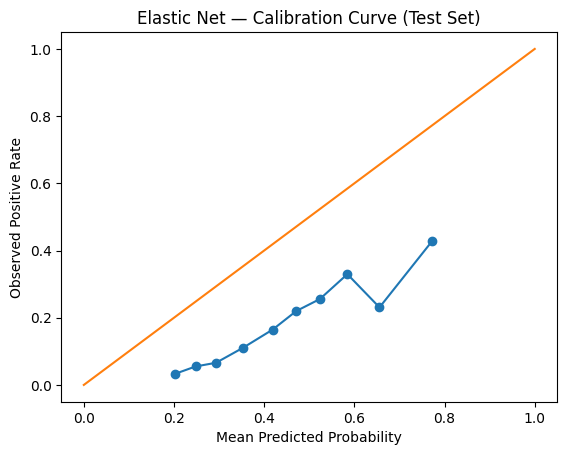

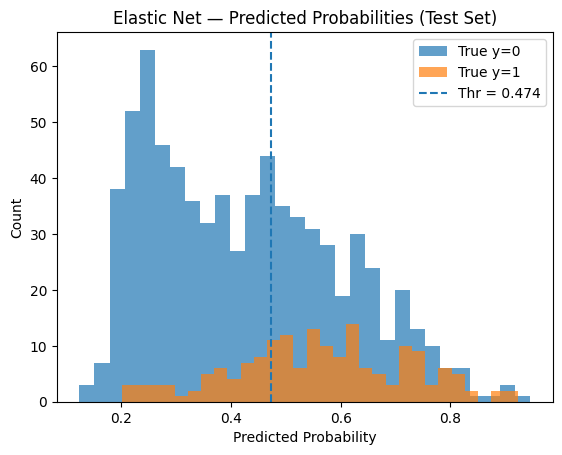


Top positive coefficients (risk factors):
                     feature      coef  odds_ratio  abs_coef
1    DaysMarijuanaPast12M_W4  0.229967    1.258558  0.229967
17     EverTried_Cigarette_Z  0.126755    1.135139  0.126755
4          Delinquency_Index  0.118829    1.126177  0.118829
18  Trouble Paying Attention  0.117079    1.124209  0.117079
22    LowReligiosityIndex_W1  0.112230    1.118771  0.112230
20            Attractive_Sex  0.097508    1.102420  0.097508
3         SchoolSuspension_Z  0.058728    1.060487  0.058728
7        SchoolTrouble_Index  0.047583    1.048733  0.047583
13        Rev_FeelGuilty_Sex  0.040136    1.040953  0.040136
8        PeerSubstance_Index  0.034931    1.035548  0.034931
2         SexAttitudes_Index  0.034892    1.035508  0.034892
12                 GPA_Index  0.020575    1.020788  0.020575
21          ExpectCollege_W1  0.015839    1.015965  0.015839
14               Relax_Sex_Z  0.014631    1.014739  0.014631
28   DrinkFrequency_Past12mo  0.010260    

In [18]:
# ============================================================
# ELASTIC NET LOGISTIC REGRESSION — COLLINEARITY FILTER (>0.85)
# + TUNING + YOUDEN (CORRECT WAY: TRAIN-ONLY CV=5 OOF)
# + FINAL TEST METRICS + FIGURES (CM, ROC, PR, CALIBRATION, PROB DIST)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import StratifiedKFold, cross_val_predict

from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve


# ------------------------------------------------
# 0) COPY DATA
# ------------------------------------------------
X_train2 = X_train.copy()
X_test2  = X_test.copy()
y_train_np = np.asarray(y_train)





# ------------------------------------------------
# 2) HELPER: YOUDEN THRESHOLD
# ------------------------------------------------
def youden_threshold(y_true, y_prob):
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    j = tpr - fpr
    idx = np.argmax(j)
    return thr[idx], j[idx], tpr[idx], 1 - fpr[idx]


# ------------------------------------------------
# 3) TUNED ELASTIC NET LOGISTIC REGRESSION
#    (tuning inside training; explicitly show C grid)
# ------------------------------------------------
pipe_en = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("lr", LogisticRegressionCV(
        Cs=np.logspace(-4, 4, 20),     # explicit C grid (transparent)
        cv=3,                          # tuning CV (set 5 if you want; 3 is common for speed)
        penalty="elasticnet",
        solver="saga",
        l1_ratios=[0.1, 0.3, 0.5, 0.7, 0.9],
        scoring="roc_auc",
        class_weight="balanced",
        max_iter=5000,
        n_jobs=-1,
        refit=True
    ))
])

# Fit FINAL model on full training set
pipe_en.fit(X_train2, y_train)

best_C = pipe_en.named_steps["lr"].C_[0]
best_l1 = pipe_en.named_steps["lr"].l1_ratio_[0] if hasattr(pipe_en.named_steps["lr"], "l1_ratio_") else None
print("\nBest C (from tuning):", best_C)
if best_l1 is not None:
    print("Best l1_ratio (from tuning):", best_l1)


# ------------------------------------------------
# 4) YOUDEN THRESHOLD (CORRECT: TRAIN ONLY, CV=5 OOF)
# ------------------------------------------------
cv_youden = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_prob = cross_val_predict(
    pipe_en,
    X_train2,
    y_train,
    cv=cv_youden,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

best_thr, best_j, sens, spec = youden_threshold(y_train, oof_prob)

print("\n=======================================")
print(" Youden threshold (TRAIN OOF, CV=5):", round(best_thr, 4))
print(" Youden J:", round(best_j, 4))
print(" Sensitivity:", round(sens, 4))
print(" Specificity:", round(spec, 4))
print("=======================================")


# ------------------------------------------------
# 5) FINAL TEST EVALUATION (single report)
# ------------------------------------------------
y_prob_test = pipe_en.predict_proba(X_test2)[:, 1]
test_auc = roc_auc_score(y_test, y_prob_test)
ap = average_precision_score(y_test, y_prob_test)

y_pred_test = (y_prob_test >= best_thr).astype(int)
cm = confusion_matrix(y_test, y_pred_test)

print("\n=======================================")
print(" ELASTIC NET LOGISTIC — TEST RESULTS")
print("=======================================")
print("Test AUC:", round(test_auc, 4))
print("Test PR–AUC:", round(ap, 4))
print("Threshold used (Youden):", round(best_thr, 4))
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_test, digits=3))


# ============================================================
# 6) FIGURES
# ============================================================

# 6.1 Colored Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-heavy use", "Heavy use"]
)
fig, ax = plt.subplots()
disp.plot(ax=ax)
ax.set_title(f"Elastic Net — Confusion Matrix (thr={best_thr:.3f})")
plt.show()

# 6.2 ROC Curve (TEST)
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {test_auc:.3f}")
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Elastic Net — ROC Curve (Test Set)")
plt.legend()
plt.show()

# 6.3 Precision–Recall Curve (TEST)
prec, rec, _ = precision_recall_curve(y_test, y_prob_test)
plt.figure()
plt.plot(rec, prec, label=f"Avg Precision = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Elastic Net — Precision–Recall Curve (Test Set)")
plt.legend()
plt.show()

# 6.4 Calibration Curve (TEST)
prob_true, prob_pred = calibration_curve(
    y_test, y_prob_test, n_bins=10, strategy="quantile"
)
plt.figure()
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1])
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Positive Rate")
plt.title("Elastic Net — Calibration Curve (Test Set)")
plt.show()

# 6.5 Probability Distributions (TEST) + threshold
y_test_np = np.asarray(y_test)
plt.figure()
plt.hist(y_prob_test[y_test_np == 0], bins=30, alpha=0.7, label="True y=0")
plt.hist(y_prob_test[y_test_np == 1], bins=30, alpha=0.7, label="True y=1")
plt.axvline(best_thr, linestyle="--", label=f"Thr = {best_thr:.3f}")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Elastic Net — Predicted Probabilities (Test Set)")
plt.legend()
plt.show()


# ------------------------------------------------
# 7) COEFFICIENTS (FINAL, INTERPRETABLE OUTPUT)
# ------------------------------------------------
coef = pipe_en.named_steps["lr"].coef_[0]
coef_df = pd.DataFrame({
    "feature": X_train2.columns,
    "coef": coef
}).sort_values("coef", ascending=False)
coef_df["odds_ratio"] = np.exp(coef_df["coef"])
coef_df["abs_coef"] = coef_df["coef"].abs()
print("\nTop positive coefficients (risk factors):")
print(coef_df.head(15))

print("\nTop negative coefficients (protective factors):")
print(coef_df.tail(15))


## Random Forest

Running RandomizedSearchCV...
Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best CV AUC (tuning, CV=3): 0.7522
Best Parameters:
{'n_estimators': 1600, 'min_samples_split': 5, 'min_samples_leaf': 10, 'min_impurity_decrease': 0.0001, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': 'balanced', 'bootstrap': True}

YOUDEN THRESHOLD (TRAIN ONLY, CV=5 OOF)
Youden threshold: 0.4191
Youden J (train OOF): 0.3969
Sensitivity (TPR) @ thr: 0.7082
Specificity (TNR) @ thr: 0.6887

RANDOM FOREST — FINAL TEST PERFORMANCE (YOUDEN)

Test ROC–AUC: 0.7222
Test PR–AUC : 0.3298
Threshold used (Youden, from train OOF): 0.4191

Accuracy : 0.6773
Precision: 0.3305
Recall   : 0.6860
F1-score : 0.4461

Confusion Matrix (Test):
 [[497 239]
 [ 54 118]] 

Classification Report (Test):
              precision    recall  f1-score     support
0              0.901996  0.675272  0.772339  736.000000
1              0.330532  0.686047  0.446125  172.000000
accuracy       0.677313  0.677313  0.67

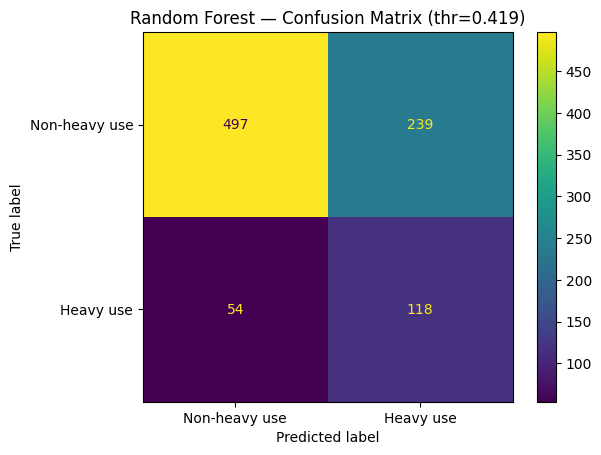

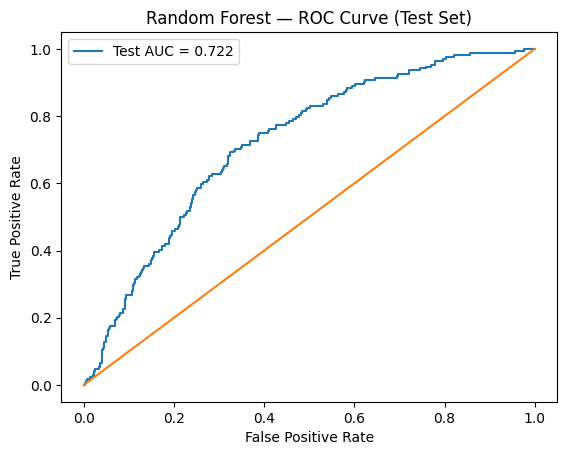

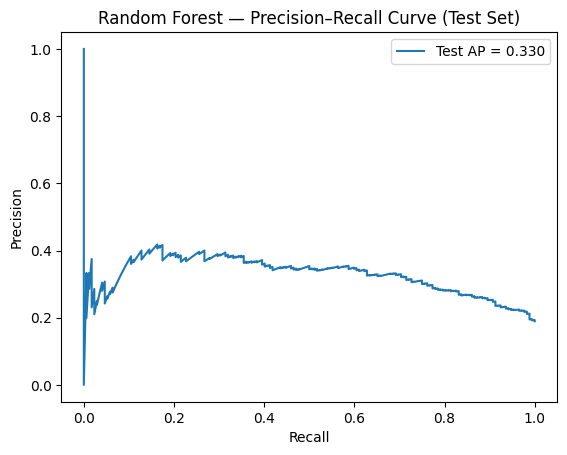

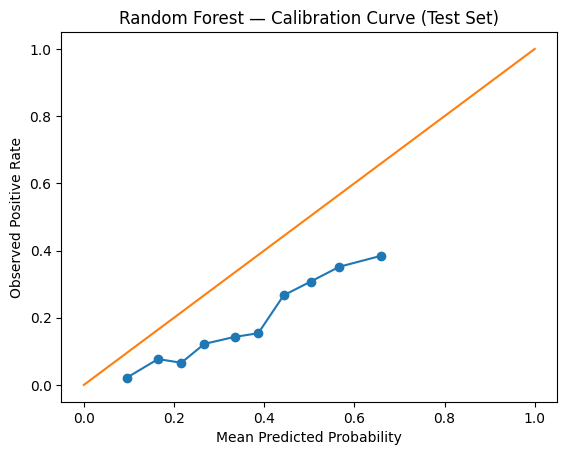

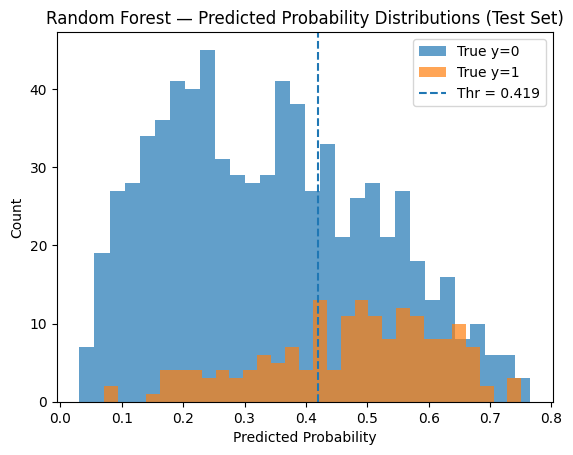


Best RF estimator:
RandomForestClassifier(class_weight='balanced', min_impurity_decrease=0.0001,
                       min_samples_leaf=10, min_samples_split=5,
                       n_estimators=1600, n_jobs=-1, random_state=42)


In [19]:
# ============================================================
# RANDOM FOREST — TUNING (CV=3) + YOUDEN (CORRECT: TRAIN-ONLY CV=5 OOF)
# + FINAL TEST METRICS + FIGURES (COLORED CM, ROC, PR, CALIBRATION, PROB DIST)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve

# ----------------------------
# 0) SETTINGS
# ----------------------------
RANDOM_STATE = 42

# Tuning CV (your preference)
cv_tune = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Youden threshold CV (train-only, more stable)
cv_youden = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ----------------------------
# 1) BASE MODEL
# ----------------------------
rf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# ----------------------------
# 2) TUNING SPACE (your grid + a couple of useful additions)
#    Additions:
#    - bootstrap: can affect calibration/variance
#    - min_impurity_decrease: small regularization knob (optional)
# ----------------------------
param_dist = {
    'n_estimators': [300, 500, 800, 1200, 1600],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 6, 10],
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.8, None],
    'class_weight': ['balanced', 'balanced_subsample', None],
    'bootstrap': [True, False],
    'min_impurity_decrease': [0.0, 0.0001, 0.001]
}

rs = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=40,
    scoring='roc_auc',
    cv=cv_tune,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=False
)

print("Running RandomizedSearchCV...")
rs.fit(X_train2, y_train)

print("\nBest CV AUC (tuning, CV=3):", round(rs.best_score_, 4))
print("Best Parameters:")
print(rs.best_params_)

best_rf = rs.best_estimator_  # best hyperparameters (refit=True by default)

# ----------------------------
# 3) YOUDEN THRESHOLD (CORRECT WAY)
#    - compute OOF probabilities on TRAIN ONLY using CV=5
# ----------------------------
def youden_from_probs(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    youden_j = tpr - fpr
    best_idx = np.argmax(youden_j)
    return thresholds[best_idx], youden_j[best_idx], fpr, tpr, thresholds, youden_j, best_idx

oof_prob = cross_val_predict(
    best_rf,
    X_train2, y_train,
    cv=cv_youden,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

youden_thr, youden_j_best, fpr_oof, tpr_oof, thr_oof, youden_j_all, best_idx = youden_from_probs(y_train, oof_prob)

print("\n===============================================")
print("YOUDEN THRESHOLD (TRAIN ONLY, CV=5 OOF)")
print("===============================================")
print("Youden threshold:", round(youden_thr, 4))
print("Youden J (train OOF):", round(youden_j_best, 4))
print("Sensitivity (TPR) @ thr:", round(tpr_oof[best_idx], 4))
print("Specificity (TNR) @ thr:", round(1 - fpr_oof[best_idx], 4))

# ----------------------------
# 4) FINAL MODEL FIT ON FULL TRAIN + SINGLE TEST EVALUATION
# ----------------------------
best_rf.fit(X_train2, y_train)

y_prob_test = best_rf.predict_proba(X_test2)[:, 1]
y_pred_test = (y_prob_test >= youden_thr).astype(int)

test_auc = roc_auc_score(y_test, y_prob_test)
test_ap  = average_precision_score(y_test, y_prob_test)

cm = confusion_matrix(y_test, y_pred_test)

acc  = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, zero_division=0)
rec  = recall_score(y_test, y_pred_test, zero_division=0)
f1   = f1_score(y_test, y_pred_test, zero_division=0)

print("\n===============================================")
print("RANDOM FOREST — FINAL TEST PERFORMANCE (YOUDEN)")
print("===============================================\n")
print(f"Test ROC–AUC: {test_auc:.4f}")
print(f"Test PR–AUC : {test_ap:.4f}")
print(f"Threshold used (Youden, from train OOF): {youden_thr:.4f}\n")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}\n")

print("Confusion Matrix (Test):\n", cm, "\n")

print("Classification Report (Test):")
print(pd.DataFrame(classification_report(y_test, y_pred_test, output_dict=True)).T)

# Summary table (handy for thesis)
summary = pd.DataFrame({
    "Metric": [
        "CV ROC–AUC (tuning, best)",
        "Youden threshold (train OOF, CV=5)",
        "Youden J (train OOF, CV=5)",
        "Test ROC–AUC",
        "Test PR–AUC",
        "Test Accuracy",
        "Test Precision (class 1)",
        "Test Recall (class 1)",
        "Test F1 (class 1)"
    ],
    "Value": [
        rs.best_score_,
        youden_thr,
        youden_j_best,
        test_auc,
        test_ap,
        acc,
        prec,
        rec,
        f1
    ]
}).round(4)

print("\nFinal Performance Summary:")
print(summary)

# ============================================================
# 5) FIGURES
# ============================================================

# 5.1 COLORED CONFUSION MATRIX (Matplotlib colormap)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-heavy use", "Heavy use"]
)
fig, ax = plt.subplots()
disp.plot(ax=ax)
ax.set_title(f"Random Forest — Confusion Matrix (thr={youden_thr:.3f})")
plt.show()

# 5.2 ROC CURVE (TEST)
fpr_test, tpr_test, _ = roc_curve(y_test, y_prob_test)
plt.figure()
plt.plot(fpr_test, tpr_test, label=f"Test AUC = {test_auc:.3f}")
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest — ROC Curve (Test Set)")
plt.legend()
plt.show()

# 5.3 PRECISION–RECALL CURVE (TEST)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob_test)
plt.figure()
plt.plot(rec_curve, prec_curve, label=f"Test AP = {test_ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Random Forest — Precision–Recall Curve (Test Set)")
plt.legend()
plt.show()

# 5.4 CALIBRATION CURVE (TEST)
prob_true, prob_pred = calibration_curve(y_test, y_prob_test, n_bins=10, strategy="quantile")
plt.figure()
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1])
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Positive Rate")
plt.title("Random Forest — Calibration Curve (Test Set)")
plt.show()

# 5.5 PROBABILITY DISTRIBUTIONS (TEST) + THRESHOLD
y_test_np = np.asarray(y_test)
plt.figure()
plt.hist(y_prob_test[y_test_np == 0], bins=30, alpha=0.7, label="True y=0")
plt.hist(y_prob_test[y_test_np == 1], bins=30, alpha=0.7, label="True y=1")
plt.axvline(youden_thr, linestyle="--", label=f"Thr = {youden_thr:.3f}")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Random Forest — Predicted Probability Distributions (Test Set)")
plt.legend()
plt.show()

print("\nBest RF estimator:")
print(best_rf)


## Plain Logistic Regression

In [60]:
import pandas as pd
df_logit=df_all_filtered.copy()

In [61]:
df_logit=df_logit.drop(columns=['DaysMarijuanaPast12M_W4'])

In [62]:

keep = {
    "GPA_Index",
    "ParentalWarmth_Index",
    "ParentalSupervision_Index",
    "SportsParticipation_Index"
}

cols_to_drop = [
    col for col in df_logit.columns
    if "index" in col.lower() and col not in keep
]

df_logit = df_logit.drop(columns=cols_to_drop)


In [63]:
import numpy as np
import pandas as pd

# =========================
# USER SETTINGS
# =========================
target = "TotalDrinking"  
corr_thr = 0.05                      # sensible given weak correlations
pair_corr_cut = 0.80                 # multicollinearity screen

# =========================
# 0) Basic numeric-only frame + drop rows missing target
# =========================
df = df_logit.copy()

# Keep numeric predictors only (bool allowed)
numeric_cols = df.select_dtypes(include=[np.number, "bool"]).columns.tolist()

if target not in df.columns:
    raise ValueError(f"Target '{target}' not found in df_all.")

# Ensure target is numeric
if not np.issubdtype(df[target].dtype, np.number):
    df[target] = pd.to_numeric(df[target], errors="coerce")

df = df.dropna(subset=[target])

# Candidate predictors
X_cols_all = [c for c in numeric_cols if c != target]

# Drop near-zero variance columns
low_var = [c for c in X_cols_all if df[c].nunique(dropna=True) <= 1]
X_cols_all = [c for c in X_cols_all if c not in low_var]

# =========================
# 1) Filter by correlation with target
# =========================
corrs = df[X_cols_all + [target]].corr(numeric_only=True)[target].drop(target)
corrs_abs = corrs.abs().sort_values(ascending=False)

corr_keep = corrs_abs[corrs_abs >= corr_thr].index.tolist()

# Relax threshold if too few survive
if len(corr_keep) < 10 and len(corrs_abs) > 0:
    corr_thr_relaxed = max(0.01, corr_thr / 2)
    corr_keep = corrs_abs[corrs_abs >= corr_thr_relaxed].index.tolist()
    print(f"[Info] Relaxed corr threshold to {corr_thr_relaxed:.3f}")
else:
    corr_thr_relaxed = corr_thr

print(f"[Step 1] Kept {len(corr_keep)} vars with |corr| ≥ {corr_thr_relaxed:.3f}")

# =========================
# 2) Remove multicollinearity by pairwise correlation
#    (drop weaker-to-target variable)
# =========================
X_corr = df[corr_keep].corr().abs()

to_drop = set()
cols = X_corr.columns.tolist()

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        c1, c2 = cols[i], cols[j]
        if X_corr.loc[c1, c2] >= pair_corr_cut:
            # drop the weaker variable (lower |corr with target|)
            if corrs_abs[c1] >= corrs_abs[c2]:
                to_drop.add(c2)
            else:
                to_drop.add(c1)

pairwise_keep = [c for c in corr_keep if c not in to_drop]

print(f"[Step 2] Dropped {len(to_drop)} vars with pairwise |corr| ≥ {pair_corr_cut:.2f}")
print(f"[Step 2] Remaining vars: {len(pairwise_keep)}")

# =========================
# 3) Outputs
# =========================
vars_decent_corr = corr_keep
vars_low_multicollinearity = pairwise_keep

print("\n=== FINAL FEATURE SET ===")
print(f"Variables kept (n={len(vars_low_multicollinearity)}):")
for v in vars_low_multicollinearity:
    print(v)


# =========================
# 4) Filtered dataframe (NO imputation)
# =========================
df_logit = df[vars_low_multicollinearity + [target]].copy()


[Step 1] Kept 89 vars with |corr| ≥ 0.050
[Step 2] Dropped 32 vars with pairwise |corr| ≥ 0.80
[Step 2] Remaining vars: 57

=== FINAL FEATURE SET ===
Variables kept (n=57):
Sex_Female
SchoolSuspension_Z
Age at First Drink
InjuredSomeone
LessLonely_Sex
FriendsRespect_Sex
GPA_Index
PeerWeed_Count
Rev_FeelGuilty_Sex
Relax_Sex_Z
SoldDrugs_Z
WantCollege_W1
EverTried_Cigarette_Z
Trouble Paying Attention
PhysicalFight_W1
Attractive_Sex
ExpectCollege_W1
Fight_Serious_Z
Trouble_GetAlong_Teachers_W1
Pleasure_Sex
LessReligiousServiceAttendance_W1
peer_alcohol_count
PeerCig_Count
FriendCare_W1
WeaponThreat_W1
DrinkFrequency_Past12mo
HighEduExpectations
Jumped_W1
HangoutFriends_W1
PublicRowdy_Z
LiftWeights_W1
GroupFight
LowImportance_Z
TroubleGetAlong_Students_W1
Trouble_HomeworkCompletion_W1
MotherEverSmoked
Rev_UpsetMother_Sex
HoursGames_W1
Age_FirstWholeCig
DrugsAvailable_Home
ClosenessToMother_W1
SchoolExpulsion_Z
DrinksPerOccasion_Past12mo_Z
Days_SmokedPast30_Z
Lifetime_Marijuana
Age_FirstDrin

In [64]:
df_logit["heavy_drinker"] = (df_logit["TotalDrinking"] > 40).astype(int)
y = df_logit["heavy_drinker"]

X = df_logit.drop(columns=["TotalDrinking", "heavy_drinker"])


In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


In [66]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve
import statsmodels.api as sm

# --- 1) TRAIN medians (store them)
train_medians = X_train.median(numeric_only=True)

# --- 2) Impute using TRAIN medians for both train and test
X_train_imp = X_train.fillna(train_medians)
X_test_imp  = X_test.fillna(train_medians)

# --- 3) Scale using TRAIN statistics
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)

# Keep names for statsmodels
feature_names = X_train.columns.tolist()


In [67]:
from sklearn.linear_model import LogisticRegression
lr_plain = LogisticRegression(penalty=None, solver="lbfgs", max_iter=5000)
lr_plain.fit(X_train_scaled, y_train)

y_pred_prob = lr_plain.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
best_threshold = thresholds[best_idx]

y_pred_class = (y_pred_prob >= best_threshold).astype(int)

print("AUC:", roc_auc_score(y_test, y_pred_prob))
print("Optimal threshold (Youden J):", round(best_threshold, 4))
print("\nClassification report:\n", classification_report(y_test, y_pred_class))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_class))


AUC: 0.6927767947421638
Optimal threshold (Youden J): 0.1687

Classification report:
               precision    recall  f1-score   support

           0       0.90      0.60      0.72       736
           1       0.30      0.73      0.42       172

    accuracy                           0.62       908
   macro avg       0.60      0.66      0.57       908
weighted avg       0.79      0.62      0.66       908


Confusion matrix:
 [[441 295]
 [ 47 125]]


In [68]:
# Build a DataFrame so statsmodels keeps names
X_train_sm = pd.DataFrame(X_train_scaled, columns=feature_names, index=X_train.index)
X_train_sm = sm.add_constant(X_train_sm, has_constant="add")

logit_model = sm.Logit(y_train.astype(float), X_train_sm.astype(float))
logit_result = logit_model.fit(method="lbfgs", disp=False)

# Results table
results_table = pd.DataFrame({
    "Variable": X_train_sm.columns,
    "Coefficient": logit_result.params,
    "Std_Error": logit_result.bse,
    "p_value": logit_result.pvalues
})

results_table["Odds_Ratio"] = np.exp(results_table["Coefficient"])
results_table = results_table[results_table["Variable"] != "const"].sort_values("p_value")

results_table


,Variable,Coefficient,Std_Error,p_value,Odds_Ratio
Sex_Female,Sex_Female,-0.613977,0.066537,2.768602e-20,0.541194
Age at First Drink,Age at First Drink,-0.174381,0.051286,6.735152e-04,0.839977
HangoutFriends_W1,HangoutFriends_W1,0.162894,0.057078,4.318576e-03,1.176912
Pleasure_Sex,Pleasure_Sex,-0.197023,0.072628,6.672375e-03,0.821172
Trouble Paying Attention,Trouble Paying Attention,0.168340,0.065224,9.852627e-03,1.183339
FriendCare_W1,FriendCare_W1,-0.138754,0.053861,9.991282e-03,0.870442
EverTried_Cigarette_Z,EverTried_Cigarette_Z,0.147166,0.062000,1.761348e-02,1.158547
HouseholdSmokes,HouseholdSmokes,0.103625,0.053603,5.321393e-02,1.109184
SchoolSuspension_Z,SchoolSuspension_Z,0.096676,0.057394,9.210026e-02,1.101503
LessReligiousServiceAttendance_W1,LessReligiousServiceAttendance_W1,0.098273,0.058906,9.525736e-02,1.103264


In [69]:
alpha = 0.05

significant_vars = results_table[
    results_table["p_value"] < alpha
].copy()

significant_vars


,Variable,Coefficient,Std_Error,p_value,Odds_Ratio
Sex_Female,Sex_Female,-0.613977,0.066537,2.768602e-20,0.541194
Age at First Drink,Age at First Drink,-0.174381,0.051286,6.735152e-04,0.839977
HangoutFriends_W1,HangoutFriends_W1,0.162894,0.057078,4.318576e-03,1.176912
Pleasure_Sex,Pleasure_Sex,-0.197023,0.072628,6.672375e-03,0.821172
Trouble Paying Attention,Trouble Paying Attention,0.168340,0.065224,9.852627e-03,1.183339
FriendCare_W1,FriendCare_W1,-0.138754,0.053861,9.991282e-03,0.870442
EverTried_Cigarette_Z,EverTried_Cigarette_Z,0.147166,0.062000,1.761348e-02,1.158547
